In [1]:
import os
import glob
import gc
from pathlib import Path

import numpy as np
from sklearn import linear_model
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
DREAMLET_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'
CRUMBLR_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/crumblr_outs/'

In [3]:
vp_df = pd.read_csv(Path(DREAMLET_PATH) / 'variance_partition_long.csv')

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


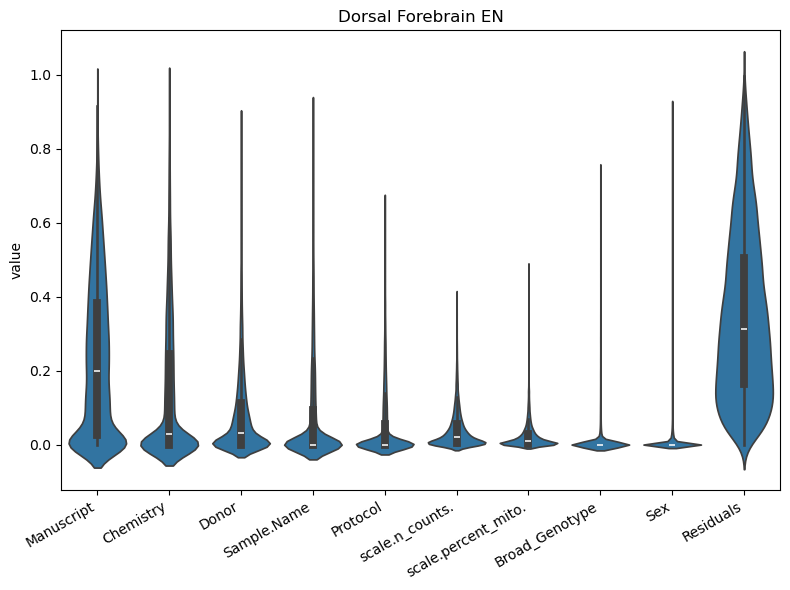

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


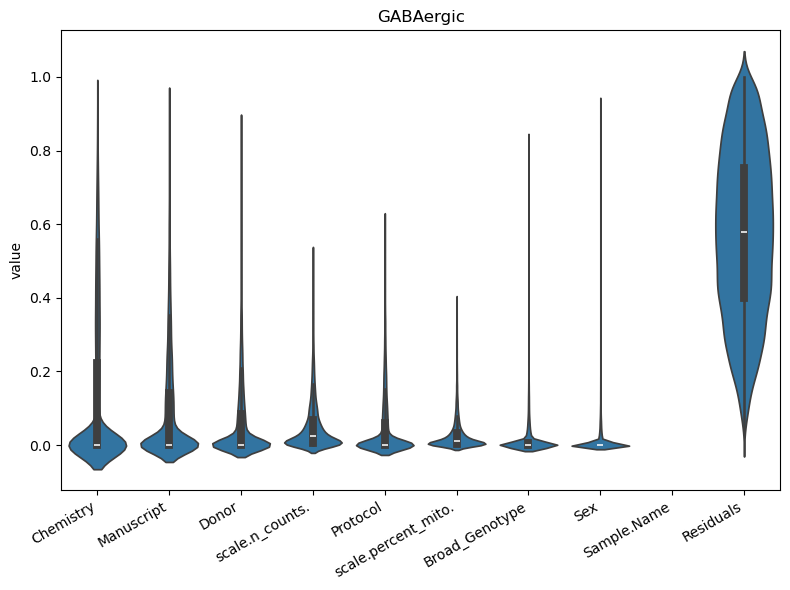

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


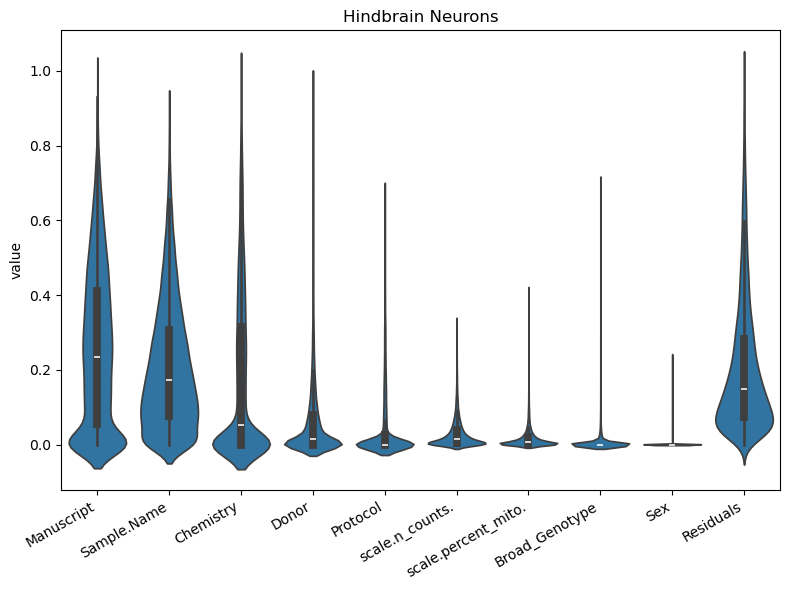

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


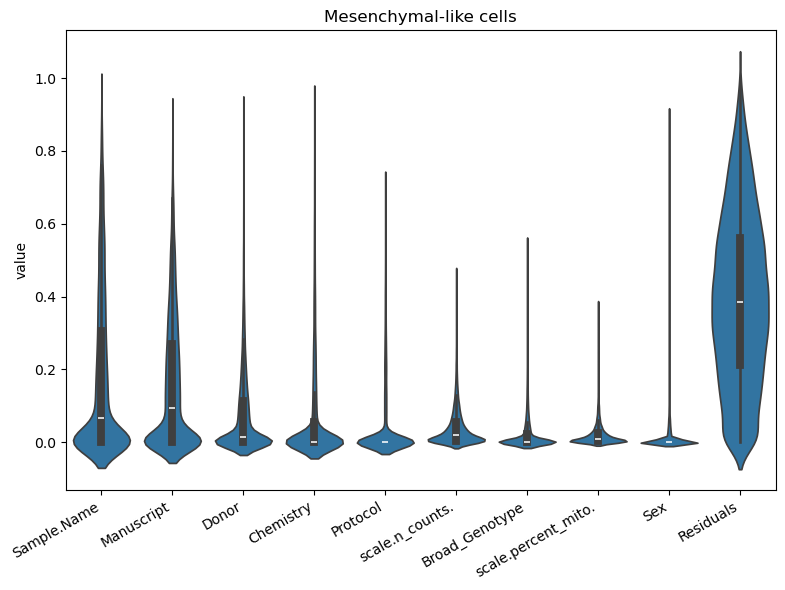

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


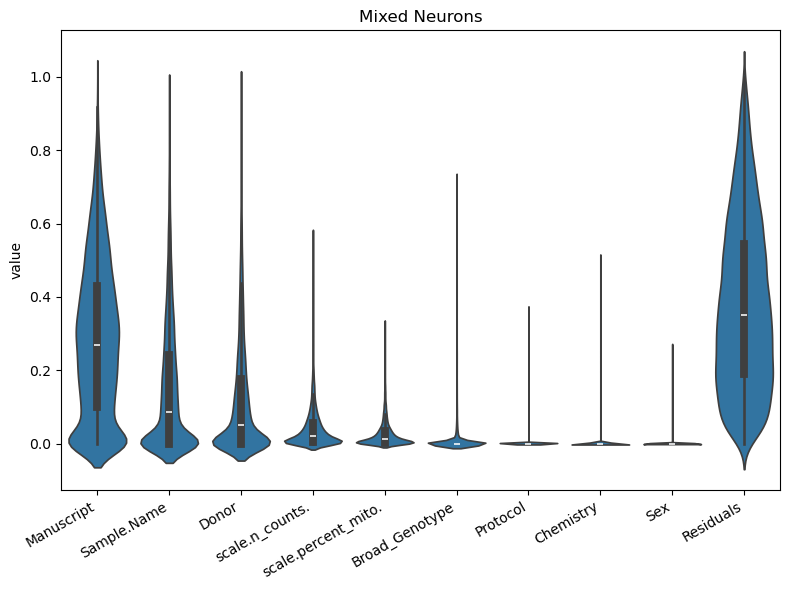

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


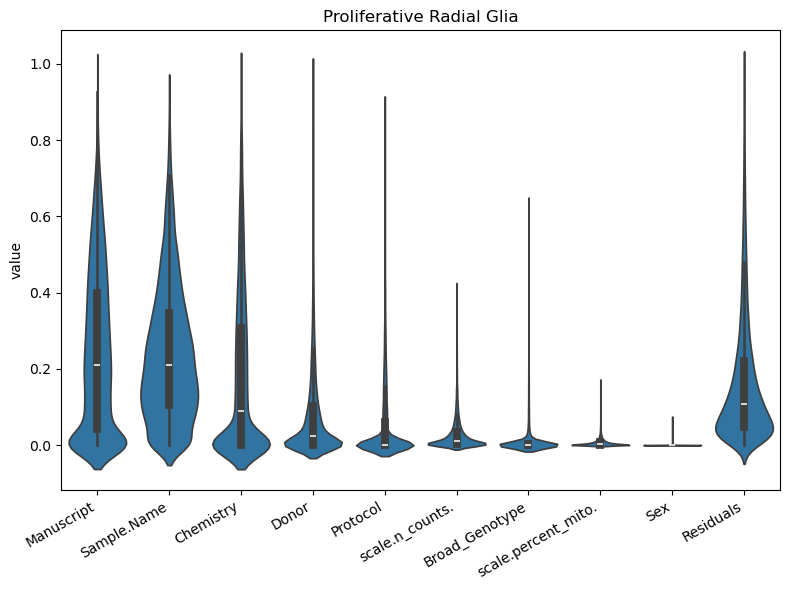

/tmp/ipykernel_162131/1044953072.py:23: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/1044953072.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


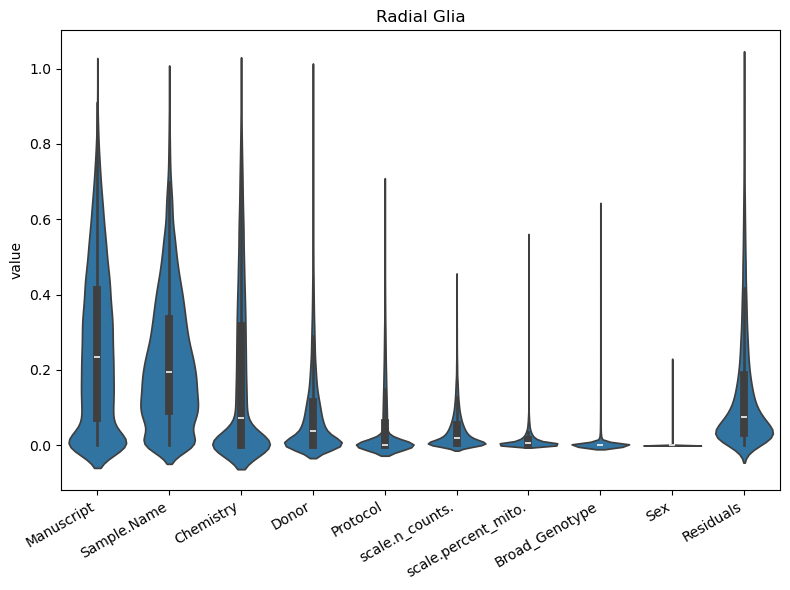

In [4]:
## Plotting Variance Partitioning by Cell Type ##

for cell_type in vp_df['assay'].unique():
    
    vp_adaptive_melted = pd.melt(vp_df[vp_df['assay'] == cell_type], id_vars='gene')
    
    vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']
    
    # Step 1: Compute mean values (excluding 'residuals')
    means = (
        vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
        .groupby('variable')['value']
        .mean()
        .sort_values(ascending=False)
    )
    
    # Step 2: Create new order: sorted variables + 'residuals' at the end
    new_order = list(means.index) + ['Residuals']
    
    # Step 3: Plot with ordered categories
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.title(cell_type)
    sns.violinplot(
        data=vp_adaptive_melted,
        x='variable',
        y='value',
        scale='width',
        order=new_order,
        ax=ax
    )
    plt.xlabel('')
    
    # Step 4: Rotate and align tick labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    
    plt.tight_layout()
    plt.show()

In [5]:
files = glob.glob(DREAMLET_PATH + 'dreamlet*')

dfs = []
for f in files:
    temp = pd.read_csv(f)
    # Add a column based on the filename
    temp['source_key'] = f.split('/')[-1].split('_')[1]  # or however you want to extract it
    dfs.append(temp)

# Concatenate all, resetting the index
df = pd.concat(dfs, ignore_index=True)

In [6]:
df[(df['logFC'] > 1) & (df['adj.P.Val'] < 0.05)]['source_key'].value_counts()

source_key
Idiopathic    724
15q13           8
3q29            7
22q11           1
Name: count, dtype: int64

In [7]:
stacked_df = pd.read_csv(Path(DREAMLET_PATH) / 'variance_partition_long_stacked.csv')

/tmp/ipykernel_162131/3006513299.py:19: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_162131/3006513299.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


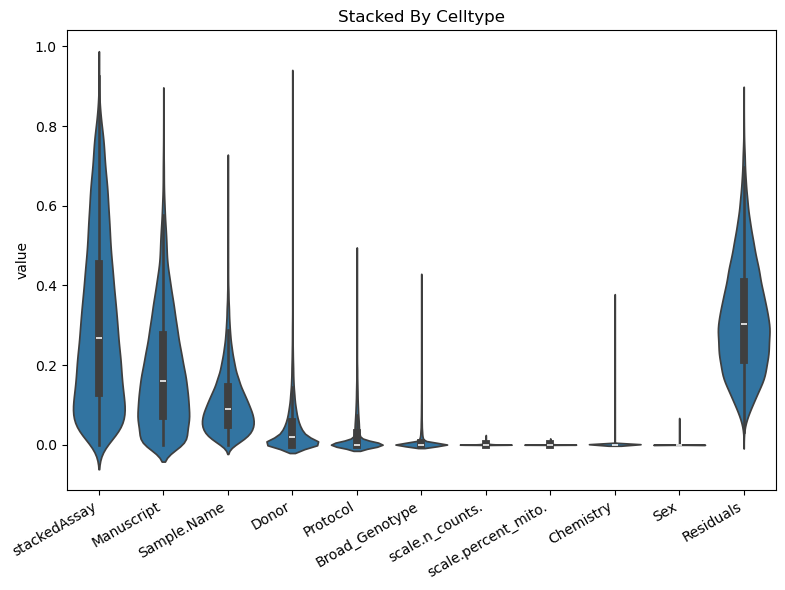

In [8]:
vp_adaptive_melted = pd.melt(stacked_df, id_vars='gene')

vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']

# Step 1: Compute mean values (excluding 'residuals')
means = (
    vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
    .groupby('variable')['value']
    .mean()
    .sort_values(ascending=False)
)

# Step 2: Create new order: sorted variables + 'residuals' at the end
new_order = list(means.index) + ['Residuals']

# Step 3: Plot with ordered categories
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Stacked By Celltype')
sns.violinplot(
    data=vp_adaptive_melted,
    x='variable',
    y='value',
    scale='width',
    order=new_order,
    ax=ax
)
plt.xlabel('')

# Step 4: Rotate and align tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()